In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    absolute_error = np.empty(max_iterations)
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        error = np.linalg.norm(x_new - x, ord=np.inf) # Absolute error between each iteration
        absolute_error[k] = error # Storing the error
            
        # Check for convergence
        if error < tol:
            return x_new, k, absolute_error[:k+1]
        
        x = x_new
        
    return x, max_iterations, absolute_error


In [73]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    absolute_error = np.empty(max_iterations)
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        error = np.linalg.norm(x_new - x, ord=np.inf) # Absolute error between each iteration
        absolute_error[k] = error # Storing the error
            
        # Check for convergence
        if error < tol:
            return x_new, k, absolute_error[:k+1]
        
        x = x_new
    return x, max_iterations, absolute_error

In [74]:
def plot_Gauss_Seibel(absolute_error_GS_1, absolute_error_GS_2, absolute_error_GS_3):
    plt.figure()
    plt.plot(absolute_error_GS_1)
    plt.xlabel("Number of iterations")
    plt.ylabel("Absolute Error")
    plt.title("Gauss-Seidel at Tolerance 1e-3")
    plt.show()
    
    plt.figure()
    plt.plot(absolute_error_GS_2)
    plt.xlabel("Number of iterations")
    plt.ylabel("Absolute Error")
    plt.title("Gauss-Seidel at Tolerance 1e-6")
    plt.show()
    
    plt.figure()
    plt.plot(absolute_error_GS_3)
    plt.xlabel("Number of iterations")
    plt.ylabel("Absolute Error")
    plt.title("Gauss-Seidel at Tolerance 1e-9")
    plt.show()

In [75]:
def plot_Jacobi(absolute_error_J_1, absolute_error_J_2, absolute_error_J_3):
    plt.figure()
    plt.plot(absolute_error_J_1)
    plt.xlabel("Number of iterations")
    plt.ylabel("Absolute Error")
    plt.title("Jacobi at Tolerance 1e-3")
    plt.show()
    
    plt.figure()
    plt.plot(absolute_error_J_2)
    plt.xlabel("Number of iterations")
    plt.ylabel("Absolute Error")
    plt.title("Jacobi at Tolerance 1e-6")
    plt.show()
    
    plt.figure()
    plt.plot(absolute_error_J_3)
    plt.xlabel("Number of iterations")
    plt.ylabel("Absolute Error")
    plt.title("Jacobi at Tolerance 1e-9")
    plt.show()
    

Tolerance   Gauss-Seidel Iterations     Jacobi Iterations 
1e-03       3                           3                 
1e-06       4                           6                 
1e-09       6                           8                 


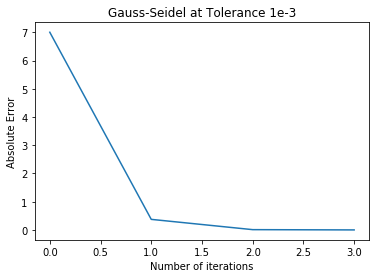

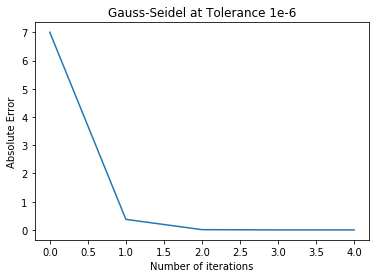

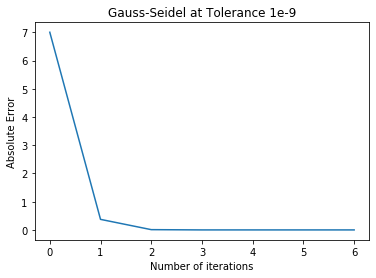

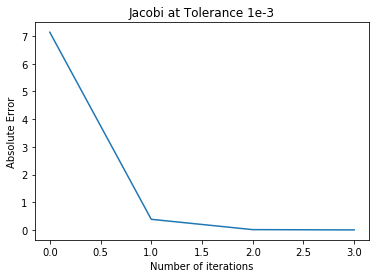

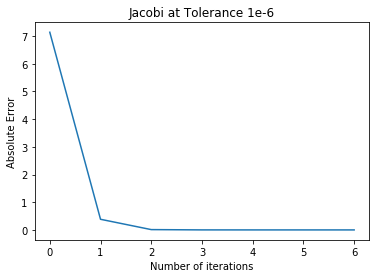

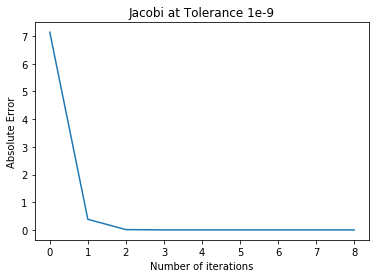

In [86]:
def main():
    A = np.array([[3., -0.1, -0.2],
                 [0.1, 7., -0.3],
                 [0.3, -0.2, 10.]])
    
    b = np.array([7.85,-19.3, 71.4])
    x0 = np.zeros(len(b))
    tol = np.array([1e-3, 1e-6, 1e-9])
    max_iterations = 100
    
    
    solution_GS_1, iterations_GS_1, absolute_error_GS_1 = gauss_seidel(A, b, x0, tol[0], max_iterations)
    solution_J_1, iterations_J_1, absolute_error_J_1 = jacobi(A, b, x0, tol[0], max_iterations)
    
    solution_GS_2, iterations_GS_2, absolute_error_GS_2 = gauss_seidel(A, b, x0, tol[1], max_iterations)
    solution_J_2, iterations_J_2, absolute_error_J_2 = jacobi(A, b, x0, tol[1], max_iterations)
    
    solution_GS_3, iterations_GS_3, absolute_error_GS_3 = gauss_seidel(A, b, x0, tol[2], max_iterations)
    solution_J_3, iterations_J_3, absolute_error_J_3 = jacobi(A, b, x0, tol[2], max_iterations)
    
    
    iterations = np.array([iterations_GS_1, iterations_J_1,
                          iterations_GS_2, iterations_J_2,
                          iterations_GS_3, iterations_J_3])
    
    
    print(f"{'Tolerance':<12}{'Gauss-Seidel Iterations':<28}{'Jacobi Iterations':<18}")
    print(f"{tol[0]:<12.0e}{iterations_GS_1:<28}{iterations_J_1:<18}")
    print(f"{tol[1]:<12.0e}{iterations_GS_2:<28}{iterations_J_2:<18}")
    print(f"{tol[2]:<12.0e}{iterations_GS_3:<28}{iterations_J_3:<18}")


    plot_Gauss_Seibel(absolute_error_GS_1, absolute_error_GS_2, absolute_error_GS_3)
    plot_Jacobi(absolute_error_J_1, absolute_error_J_2, absolute_error_J_3)
 
    
        
if __name__ == "__main__":
    main()

In [ ]:
# As the tolerance gets smaller, it usually takes more iterations
# because the error has to get below a smaller number.